<a href="https://colab.research.google.com/github/9terry-student/PyTorch/blob/main/23_%EC%96%B4%ED%85%90%EC%85%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 23장 AI가 문맥을 파악하는 원리

In [1]:
!apt-get install -y fonts-nanum
!fc-cache -fv
!rm -rf ~/.cache/matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 45 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

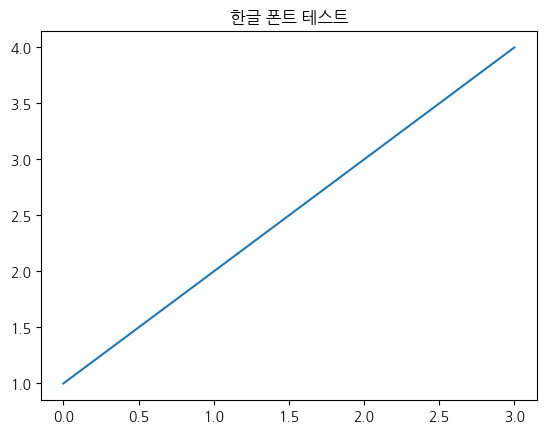

In [2]:
import matplotlib.pyplot as plt

plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

plt.plot([1, 2, 3, 4])
plt.title('한글 폰트 테스트')
plt.show()

## 23-1 단어 간 유사성 측정하기

컴퓨터가 알아 들을 수 있도록 수치 형태로 변환하기

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 단어와 임베딩 벡터 정의
word_embeddings={
    '귤': np.array([0,6]),
    '딸기': np.array([0,5]),
    '수박': np.array([1,6]),
    '미소짓다': np.array([6,1]),
    '화내다': np.array([6,0]),
    '웃다': np.array([5,0])
}

# 출력
for word,vec in word_embeddings.items():
    print(f"'{word}'의 임베딩 벡터: {vec}")

'귤'의 임베딩 벡터: [0 6]
'딸기'의 임베딩 벡터: [0 5]
'수박'의 임베딩 벡터: [1 6]
'미소짓다'의 임베딩 벡터: [6 1]
'화내다'의 임베딩 벡터: [6 0]
'웃다'의 임베딩 벡터: [5 0]


단어를 시각화하기

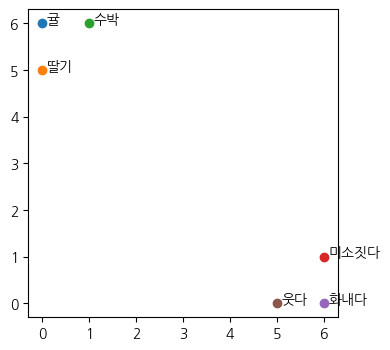

In [4]:
plt.figure(figsize=(4,4))
for word,vec in word_embeddings.items():
  plt.scatter(*vec)
  plt.text(vec[0]+0.1,vec[1],word)
plt.show()

## 23-2 단어들 사이의 관계 파악하기

내적 계산하기

In [5]:
def dot_product(vec1,vec2):
  return np.dot(vec1,vec2)

# 예제 단어들 사이의 내적 계산
print("귤 • 딸기:",dot_product(word_embeddings['귤'],word_embeddings['딸기']))
print("귤 • 웃다:",dot_product(word_embeddings['귤'],word_embeddings['웃다']))

귤 • 딸기: 30
귤 • 웃다: 0


코사인 유사도 계산하기

In [6]:
def cosine_similarity(v1,v2):
  return np.dot(v1,v2)/(np.linalg.norm(v1)*np.linalg.norm(v2))

words=list(word_embeddings.keys())
embedding_vectors=np.array(list(word_embeddings.values()))

# 코사인 유사성 계산
similarities=[]
for v1 in embedding_vectors:
  row=[]
  for v2 in embedding_vectors:
    row.append(cosine_similarity(v1,v2))
  similarities.append(row)

# 결과 출력
for i in range(len(words)):
  for j in range(len(words)):
    print(f'{words[i]} • {words[j]} 유사성: {similarities[i][j]:.2f}')

귤 • 귤 유사성: 1.00
귤 • 딸기 유사성: 1.00
귤 • 수박 유사성: 0.99
귤 • 미소짓다 유사성: 0.16
귤 • 화내다 유사성: 0.00
귤 • 웃다 유사성: 0.00
딸기 • 귤 유사성: 1.00
딸기 • 딸기 유사성: 1.00
딸기 • 수박 유사성: 0.99
딸기 • 미소짓다 유사성: 0.16
딸기 • 화내다 유사성: 0.00
딸기 • 웃다 유사성: 0.00
수박 • 귤 유사성: 0.99
수박 • 딸기 유사성: 0.99
수박 • 수박 유사성: 1.00
수박 • 미소짓다 유사성: 0.32
수박 • 화내다 유사성: 0.16
수박 • 웃다 유사성: 0.16
미소짓다 • 귤 유사성: 0.16
미소짓다 • 딸기 유사성: 0.16
미소짓다 • 수박 유사성: 0.32
미소짓다 • 미소짓다 유사성: 1.00
미소짓다 • 화내다 유사성: 0.99
미소짓다 • 웃다 유사성: 0.99
화내다 • 귤 유사성: 0.00
화내다 • 딸기 유사성: 0.00
화내다 • 수박 유사성: 0.16
화내다 • 미소짓다 유사성: 0.99
화내다 • 화내다 유사성: 1.00
화내다 • 웃다 유사성: 1.00
웃다 • 귤 유사성: 0.00
웃다 • 딸기 유사성: 0.00
웃다 • 수박 유사성: 0.16
웃다 • 미소짓다 유사성: 0.99
웃다 • 화내다 유사성: 1.00
웃다 • 웃다 유사성: 1.00


## 23-3 단어 사이의 관계 수정하기

관계 업데이트

In [7]:
def update_vector(vector,target_vector,similarity_value,learning_rate):
  new_vector=vector+learning_rate*(target_vector-vector)*similarity_value
  return new_vector

# 기존 딕셔너리에 추가
word_embeddings['사과']=np.array([3,3])     # '사과' 초기값 추가
word_embeddings['과']=np.array([0,0])     # '과' 벡터 추가

# 벡터값 가져오기
귤=word_embeddings['귤']
사과=word_embeddings['사과']
과=word_embeddings['과']

# '귤과 사과' 문장의 각 단어별 코사인 유사도
cosine_귤_사과=cosine_similarity(귤,사과)
cosine_과_사과=cosine_similarity(과,사과)

# 학습률1의 설정
learning_rate1=0.47

# '사과' 벡터를 '귤' 쪽으로 업데이트
print(f'업데이트 이전의 사과 벡터 (사과_?): {사과}')
사과_과일=update_vector(사과,귤,cosine_귤_사과,learning_rate1)
print(f'업데이트된 사과 벡터 (사과_과일): {사과_과일}')

업데이트 이전의 사과 벡터 (사과_?): [3 3]
업데이트된 사과 벡터 (사과_과일): [2.00297944 3.99702056]


/tmp/ipykernel_18200/2080672280.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return np.dot(v1,v2)/(np.linalg.norm(v1)*np.linalg.norm(v2))


모두 실행

업데이트 이전의 사과 벡터 (사과_?): [3 3]
업데이트된 사과 벡터 (사과_과일): [2.00297944 3.99702056]
업데이트된 사과 벡터 (사과_행위): [3.99067604 2.00932396]


/tmp/ipykernel_18200/996630942.py:15: RuntimeWarning: invalid value encountered in scalar divide
  return dot_product/(norm_v1*norm_v2)


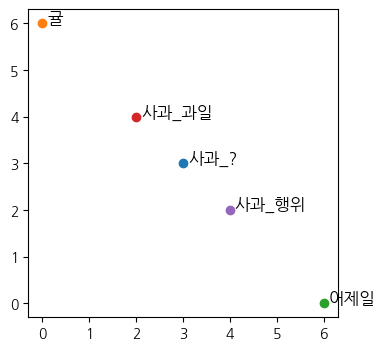

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 초기 벡터값 설정
사과=np.array([3,3])
귤=np.array([0,6])
과=np.array([0,0])
을=np.array([0,0])
어제일=np.array([6,0])

def cosine_similarity(v1,v2):
  dot_product=np.dot(v1,v2)
  norm_v1=np.linalg.norm(v1)
  norm_v2=np.linalg.norm(v2)
  return dot_product/(norm_v1*norm_v2)

def update_vector(vector,target_vector,similarity_value,learning_rate):
  new_vector=vector+learning_rate*(target_vector-vector)*similarity_value
  return new_vector

# '귤과 사과' 문장의 각 단어별 코사인 유사도
cosine_귤_사과=cosine_similarity(귤,사과)
cosine_과_사과=cosine_similarity(과,사과)

# 학습률1의 설정
learning_rate1=0.47

# '사과' 벡터를 '귤' 쪽으로 업데이트
print(f'업데이트 이전의 사과 벡터 (사과_?): {사과}')
사과_과일=update_vector(사과,귤,cosine_귤_사과,learning_rate1)
print(f'업데이트된 사과 벡터 (사과_과일): {사과_과일}')

# '어제일을 사과' 문장의 각 단어별 코사인 유사도
cosine_어제일_사과=cosine_similarity(어제일,사과_과일)
cosine_을_사과=cosine_similarity(을,사과_과일)

# 학습률2 설정
learning_rate2=1.11

# '사과' 벡터를 '어제일' 쪽으로 업데이트
사과_행위=update_vector(사과_과일,어제일,cosine_어제일_사과,learning_rate2)
print(f'업데이트된 사과 벡터 (사과_행위): {사과_행위}')

# 단어 임베딩 시각화
word_embeddings={
    '사과_?':사과,
    '귤':귤,
    '어제일':어제일,
    '사과_과일':사과_과일,
    '사과_행위':사과_행위
}

plt.figure(figsize=(4,4))
for word,vec in word_embeddings.items():
  plt.scatter(*vec)
  plt.text(vec[0]+0.1,vec[1],word,fontsize=12)

plt.show()

## 23-4 AI가 문맥을 파악하는 법

임베딩 행렬의 형태

In [9]:
embedding_dict={
    '커피':np.random.rand(512),
    '한잔':np.random.rand(512),
    '어때':np.random.rand(512),
    'PAD':np.zeros(512)     # 패딩 벡터는 0으로 채움
}

# 입력 문장
sentence=['커피','한잔','어때']
max_len=4     # 최대 문장 길이
tokens=sentence+['PAD']*(max_len-len(sentence))     # 패딩 적용

# 토큰을 임베딩 벡터로 전환
embeddings=np.array([embedding_dict[token] for token in tokens])
print('임베딩 행렬의 형태:',embeddings.shape)     # (4,512)

임베딩 행렬의 형태: (4, 512)


각 헤드의 형태

In [10]:
num_heads=8
head_dim=512//num_heads     # 각 헤드의 차원

# 임베딩을 8개의 헤드로 분할
heads=np.split(embeddings,num_heads,axis=1)
print('각 헤드의 형태:',heads[0].shape)     # (4,64)

각 헤드의 형태: (4, 64)


내적 결과 행렬의 형태

In [11]:
# 첫번째 헤드 선택
head_1=heads[0]

# 복사1과 복사2 생성
copy1=head_1
copy2=head_1.T
# 내적 계산
attention_scores=np.dot(copy1,copy2)
print('내적 결과 행렬의 형태:',attention_scores.shape)      # (4,4)

내적 결과 행렬의 형태: (4, 4)


복원된 헤드의 형태

In [12]:
# 복사3 생성
copy3=embeddings[:,:head_dim]

# 다시 4x64 형태로 변환
restored_head=np.dot(attention_scores,copy3)
print('복원된 헤드의 형태:',restored_head.shape)      # (4,64)

복원된 헤드의 형태: (4, 64)


최종 출력 행렬의 형태

In [13]:
restored_heads=[]

for i in range(num_heads):
  head=heads[i]
  copy1=head
  copy2=head.T
  attention_scores=np.dot(copy1,copy2)
  copy3=embeddings[:,i*head_dim:(i+1)*head_dim]
  restored_head=np.dot(attention_scores,copy3)
  restored_heads.append(restored_head)

# 모든 헤드를 결합하여 원래 차원으로 복원
final_output=np.concatenate(restored_heads,axis=1)
print('최종 출력 행렬의 형태:',final_output.shape)      #(4,512)

최종 출력 행렬의 형태: (4, 512)


전체 실행

In [14]:
import numpy as np

# 단어와 해당 임베딩 벡터를 딕셔너리로 정의
embedding_dict={
    '커피':np.random.rand(512),
    '한잔':np.random.rand(512),
    '어때':np.random.rand(512),
    'PAD':np.zeros(512),
}

# 입력 문장
sentence=['커피','한잔','어때']
max_len=4
tokens=sentence+['PAD']*(max_len-len(sentence))

# 토큰을 임베딩 벡터로 변환
embeddings=np.array([embedding_dict[token] for token in tokens])
print('임베딩 행렬의 형태:',embeddings.shape)

# 임베딩을 8개의 헤드로 분할
num_heads=8
head_dim=512//num_heads

heads=np.split(embeddings,num_heads,axis=1)
print('각 헤드의 형태:',heads[0].shape)

# 각 헤드 간의 내적 계산 및 복원
restored_heads=[]

for i in range(num_heads):
  head=heads[i]
  copy1=head
  copy2=head.T
  attention_score=np.dot(copy1,copy2)
  copy3=embeddings[:,i*head_dim:(i+1)*head_dim]
  restored_head=np.dot(attention_scores,copy3)
  restored_heads.append(restored_head)

# 모든 헤드를 결합하여 원래 차원으로 복원
final_output=np.concatenate(restored_heads,axis=1)
print('최종 출력 행렬의 형태:',final_output.shape)

임베딩 행렬의 형태: (4, 512)
각 헤드의 형태: (4, 64)
최종 출력 행렬의 형태: (4, 512)


## 23-5 질문(쿼리), 단서(키), 답변(밸류)

쿼리, 키, 밸류

In [15]:
# 쿼리, 키, 밸류 행렬 초기화
num_heads=8
head_dim=512//num_heads
heads=np.split(embeddings,num_heads,axis=1)
queries=heads.copy()
keys=[head.T for head in heads]
values=heads.copy()

print('쿼리 행렬의 형태:',queries[0].shape)
print('키 행렬의 형태:',keys[0].shape)
print('밸류 행렬의 형태:',values[0].shape)

쿼리 행렬의 형태: (4, 64)
키 행렬의 형태: (64, 4)
밸류 행렬의 형태: (4, 64)


스케일링 전 어텐션 스코어

In [16]:
# 스케일링 전
attention_scores=np.dot(queries[0],keys[0])
print('스케일링 전 어텐션 스코어:')
print(attention_scores)

# 스케일링을 위한 헤드 차원의 제곱근 계산
scaling_factor=np.sqrt(head_dim)

# 스케일링 후
scaled_attention_scores=attention_scores/scaling_factor
print('스케일링 후 어텐션 스코어:')
print(scaled_attention_scores)

스케일링 전 어텐션 스코어:
[[19.03150742 12.398105   15.88034758  0.        ]
 [12.398105   18.82812691 15.35181999  0.        ]
 [15.88034758 15.35181999 22.95299919  0.        ]
 [ 0.          0.          0.          0.        ]]
스케일링 후 어텐션 스코어:
[[2.37893843 1.54976312 1.98504345 0.        ]
 [1.54976312 2.35351586 1.9189775  0.        ]
 [1.98504345 1.9189775  2.8691249  0.        ]
 [0.         0.         0.         0.        ]]


소프트맥스 적용 후 어텐션 스코어

In [19]:
# 패딩 부분을 -∞로 채운 마스크 행렬 준비
mask=np.zeros_like(scaled_attention_scores)
mask[:,-1]=-np.inf
mask[-1,:]=-np.inf

# 소프트맥스 적용 함수
def masked_softmax(x,mask):
  x_exp=np.exp(x-np.max(x,axis=-1,keepdims=True))     # 오버플로우 방지
  x_exp=x_exp*(mask!=-np.inf)     # 마스크된 부분은 0으로 처리
  x_sum=np.sum(x_exp,axis=-1,keepdims=True)     # 지수 값의 합 계산
  x_sum=np.where(x_sum==0,1,x_sum)      # 0으로 나누는 것을 방지, 합이 0인 경우 1로 설정
  return x_exp/x_sum

# 소프트맥스 적용
attention_probs=masked_softmax(scaled_attention_scores,mask)
print('소프트맥스 적용 후 어텐션 스코어:')
print(attention_probs)

소프트맥스 적용 후 어텐션 스코어:
[[0.47374641 0.20674722 0.31950637 0.        ]
 [0.21365211 0.47727925 0.30906864 0.        ]
 [0.22952473 0.21485102 0.55562425 0.        ]
 [0.         0.         0.         0.        ]]


전체 실행

In [21]:
import numpy as np

# 전체 출력 형식을 소수점 이하 네 자리로 설정
np.set_printoptions(precision=4,suppress=True)

# 단어와 해당 임베딩 벡터를 딕셔너리로 정의
embedding_dict={
    '커피':np.random.rand(512),
    '한잔':np.random.rand(512),
    '어때':np.random.rand(512),
    'PAD':np.zeros(512),
}

# 입력 문장
sentence=['커피','한잔','어때']
max_len=4
tokens=sentence+['PAD']*(max_len-len(sentence))

# 토큰을 임베딩 벡터로 변환
embeddings=np.array([embedding_dict[token] for token in tokens])
print('임베딩 행렬의 형태:',embeddings.shape)

# 쿼리, 키, 밸류 행렬 초기화
num_heads=8
head_dim=512//num_heads
heads=np.split(embeddings,num_heads,axis=1)
queries=heads.copy()
keys=[head.T for head in heads]
values=heads.copy()

print('쿼리 행렬의 형태:',queries[0].shape)
print('키 행렬의 형태:',keys[0].shape)
print('밸류 행렬의 형태:',values[0].shape)

# 스케일링 전
attention_scores=np.dot(queries[0],keys[0])
print('스케일링 전 어텐션 스코어:')
print(attention_scores)

# 스케일링을 위한 헤드 차원의 제곱근 계산
scaling_factor=np.sqrt(head_dim)

# 스케일링 후
scaled_attention_scores=attention_scores/scaling_factor
print('스케일링 후 어텐션 스코어:')
print(scaled_attention_scores)

# 패딩 부분을 -∞로 채운 마스크 행렬 준비
mask=np.zeros_like(scaled_attention_scores)
mask[:,-1]=-np.inf
mask[-1,:]=-np.inf

# 소프트맥스 적용 함수
def masked_softmax(x,mask):
  x_exp=np.exp(x-np.max(x,axis=-1,keepdims=True))
  x_exp=x_exp*(mask!=-np.inf)
  x_sum=np.sum(x_exp,axis=-1,keepdims=True)
  x_sum=np.where(x_sum==0,1,x_sum)
  return x_exp/x_sum

# 소프트맥스 적용
attention_probs=masked_softmax(scaled_attention_scores,mask)
print('소프트맥스 적용 후 어텐션 스코어:')
print(attention_probs)

# 복원된 헤드를 저장할 리스트
restored_heads=[]

for i in range(num_heads):
  query=queries[i]
  key=keys[i]
  value=values[i]

  # 내적 계산 후 스케일링
  attention_scores=np.dot(query,key)/scaling_factor

  # 패딩 처리
  padding_mask=(np.array(tokens)=='PAD').astype(float)
  padding_mask=np.tile(padding_mask,(attention_scores.shape[0],1))
  attention_scores=np.where(padding_mask,-np.inf,attention_scores)

  # 소프트맥스 적용
  attention_weights=masked_softmax(attention_scores,padding_mask)

  # 밸류와의 곱셈
  restored_head=np.dot(attention_weights,value)
  restored_heads.append(restored_head)

# 모든 헤드를 결합하여 원래 차원으로 복원
final_output=np.concatenate(restored_heads,axis=1)
print('최종 출력 행렬의 형태:',final_output.shape)

임베딩 행렬의 형태: (4, 512)
쿼리 행렬의 형태: (4, 64)
키 행렬의 형태: (64, 4)
밸류 행렬의 형태: (4, 64)
스케일링 전 어텐션 스코어:
[[18.9605 14.4615 13.2459  0.    ]
 [14.4615 20.2802 14.6119  0.    ]
 [13.2459 14.6119 19.6032  0.    ]
 [ 0.      0.      0.      0.    ]]
스케일링 후 어텐션 스코어:
[[2.3701 1.8077 1.6557 0.    ]
 [1.8077 2.535  1.8265 0.    ]
 [1.6557 1.8265 2.4504 0.    ]
 [0.     0.     0.     0.    ]]
소프트맥스 적용 후 어텐션 스코어:
[[0.4856 0.2767 0.2377 0.    ]
 [0.2446 0.5062 0.2492 0.    ]
 [0.2273 0.2696 0.5031 0.    ]
 [0.     0.     0.     0.    ]]
최종 출력 행렬의 형태: (4, 512)


## 23-6 트랜스포머를 위한 어텐션 만들기

여러 문장의 임베딩

In [23]:
# 입력 문장
sentences=[
    ['<sos>','커피','한잔','어때','<eos>'],
    ['<sos>','오늘','날씨','좋네','<eos>'],
    ['<sos>','옷이','어울려요','<eos>','PAD']
]

# 단어와 해당 임베딩 벡터를 딕셔너리로 정의
embedding_dict={
    '<sos>':np.random.rand(512),
    '<eos>':np.random.rand(512),
    '커피':np.random.rand(512),
    '한잔':np.random.rand(512),
    '어때':np.random.rand(512),
    '오늘':np.random.rand(512),
    '날씨':np.random.rand(512),
    '좋네':np.random.rand(512),
    '옷이':np.random.rand(512),
    '어울려요':np.random.rand(512),
    'PAD':np.zeros(512)
}

max_len=5

# 토큰을 임베딩 벡터로 변환
embeddings=np.array([[embedding_dict[token] for token in sentence] for sentence in sentences])
print('임베딩 행렬의 형태:',embeddings.shape)

임베딩 행렬의 형태: (3, 5, 512)


여러 문장에서의 키, 쿼리, 밸류

In [24]:
# 쿼리, 키, 밸류 행렬 초기화
num_heads=8
head_dim=512//num_heads
heads=np.split(embeddings,num_heads,axis=2)
queries=heads.copy()
keys=[head.transpose(0,2,1) for head in heads]
values=heads.copy()

print('쿼리 행렬의 형태:',queries[0].shape)
print('키 행렬의 형태:',keys[0].shape)
print('밸류 행렬의 형태:',values[0].shape)

쿼리 행렬의 형태: (3, 5, 64)
키 행렬의 형태: (3, 64, 5)
밸류 행렬의 형태: (3, 5, 64)


전체 코드

In [27]:
import numpy as np

# 전체 출력 형식을 소수점 이하 네 자리로 설정
np.set_printoptions(precision=4,suppress=True)

# 단어와 해당 임베딩 벡터를 딕셔너리로 정의
embedding_dict={
    '<sos>':np.random.rand(512),
    '<eos>':np.random.rand(512),
    '커피':np.random.rand(512),
    '한잔':np.random.rand(512),
    '어때':np.random.rand(512),
    '오늘':np.random.rand(512),
    '날씨':np.random.rand(512),
    '좋네':np.random.rand(512),
    '옷이':np.random.rand(512),
    '어울려요':np.random.rand(512),
    'PAD':np.zeros(512)
}

# 입력 문장
sentences=[
    ['<sos>','커피','한잔','어때','<eos>'],
    ['<sos>','오늘','날씨','좋네','<eos>'],
    ['<sos>','옷이','어울려요','<eos>','PAD']
]
max_len=5

# 토큰을 임베딩 벡터로 변환
embeddings=np.array([[embedding_dict[token] for token in sentence] for sentence in sentences])
print('임베딩 행렬의 형태:',embeddings.shape)

# 쿼리, 키, 밸류 행렬 초기화
num_heads=8
head_dim=512//num_heads
heads=np.split(embeddings,num_heads,axis=2)
queries=heads.copy()
keys=[head.transpose(0,2,1) for head in heads]
values=heads.copy()

print('쿼리 행렬의 형태:',queries[0].shape)
print('키 행렬의 형태:',keys[0].shape)
print('밸류 행렬의 형태:',values[0].shape)

# 특정 토큰의 인덱스
tokens_of_interest=['커피','한잔','어때']
indices_of_interest=[sentences[0].index(token) for token in tokens_of_interest]

# 어텐션 이전의 임베딩 테이블 중 특정 토큰들의 평균값 계산
print("어텐션 이전의 임베딩 테이블 중 '커피', '한잔', '어때' 토큰의 평균값:")
initial_avg=np.mean(embeddings[0,indices_of_interest,:],axis=1)
print(initial_avg)

# 스케일링 및 어텐션 스코어 계산
attention_scores=np.matmul(queries[0],keys[0])
scaling_factor=np.sqrt(head_dim)
scaled_attention_scores=attention_scores/scaling_factor

# 패딩 처리
mask=np.array([[token=='PAD' for token in sentence] for sentence in sentences])
mask=mask[:,np.newaxis,:]     # 차원을 맞추기 위해 확장
scaled_attention_scores=np.where(mask,-np.inf,scaled_attention_scores)

# 소프트맥스 적용 함수
def softmax(x):
  exp_x=np.exp(x-np.max(x,axis=-1,keepdims=True))
  return exp_x/np.sum(exp_x,axis=-1,keepdims=True)

# 복원된 헤드를 저장할 리스트
restored_heads=[]

for i in range(num_heads):
  query=queries[i]
  key=keys[i]
  value=values[i]

  # 내적 계산 후 스케일링
  attention_scores=np.matmul(query,key)/scaling_factor

  # 패딩 처리
  mask=np.array([[token=='PAD' for token in sentence] for sentence in sentences])
  mask=mask[:,np.newaxis,:]
  attention_scores=np.where(mask,-np.inf,attention_scores)

  # 소프트맥스 적용
  attention_weights=softmax(attention_scores)

  # 밸류와의 곱셈
  restored_head=np.matmul(attention_weights,value)
  restored_heads.append(restored_head)

# 모든 헤드를 결합하여 원래 차원으로 복원
final_output=np.concatenate(restored_heads,axis=2)

# 어텐션 이후의 결과 중 특정 토큰들의 평균값 계산
print("어텐션 이후의 결과 중 '커피','한잔','어때' 토큰의 평균값:")
final_avg=np.mean(final_output[0,indices_of_interest,:],axis=1)
print(final_avg)

임베딩 행렬의 형태: (3, 5, 512)
쿼리 행렬의 형태: (3, 5, 64)
키 행렬의 형태: (3, 64, 5)
밸류 행렬의 형태: (3, 5, 64)
어텐션 이전의 임베딩 테이블 중 '커피', '한잔', '어때' 토큰의 평균값:
[0.5212 0.5047 0.4993]
어텐션 이후의 결과 중 '커피','한잔','어때' 토큰의 평균값:
[0.5148 0.5123 0.5112]
